# Definindo o problema

Prática guiada sobre o uso de Graph Neural Networks (GNNs) para prever interações entre proteínas (Protein-Protein Interaction).

# Interação de Proteina - Proteina

O nosso objetivo é prever a classes do dataset protein-protein interaction feito por Agrawal. Coleção de 24 grafos, onde 21.557 são preinas humanas e 342.353 interações entre proteinas na célula humana. No total queremos prever 121 classes (problema multicasse, cada saida pode ter masid o que 1 classe)

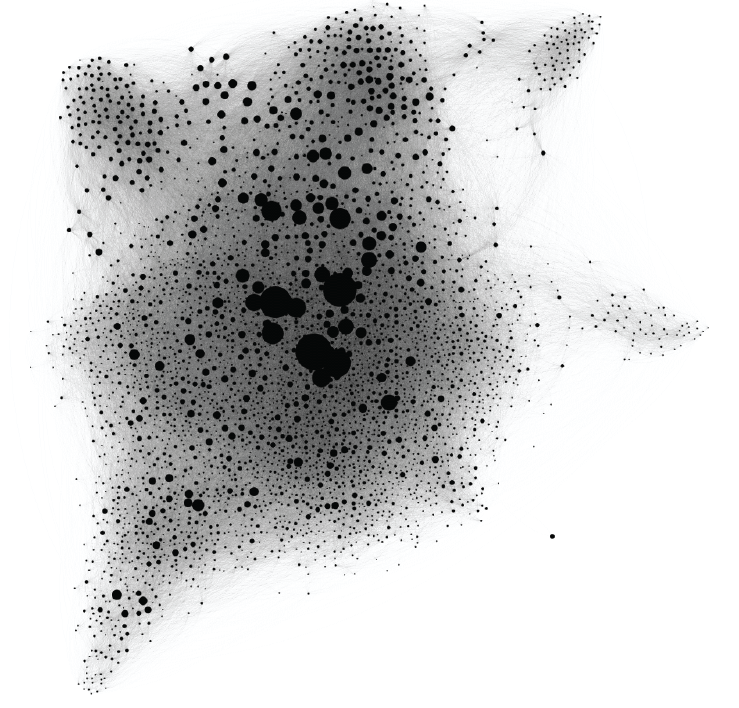

### Importando as Bibliotecas Necessárias

In [ ]:

!pip uninstall -y torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric pyg-lib > /dev/null 2>&1
import torch 
import sys 


torch_version = torch.__version__.split('+')[0]   # ex: 2.2.1
cuda_version = torch.version.cuda

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {cuda_version}")

if cuda_version is None:
    device_tag = "cpu"
else:
    device_tag = f"cu{cuda_version.replace('.', '')}"


major_minor = ".".join(torch_version.split('.')[:2])
torch_tag = f"{major_minor}.0"


url = f"https://data.pyg.org/whl/torch-{torch_tag}+{device_tag}.html"

print(f"Using wheels from: {url}")

!pip install pyg-lib torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f {url}

import torch_geometric 
import pyg_lib 

print("PyG version:", torch_geometric.__version__)
print("pyg-lib OK")

from torch_geometric.loader import NeighborLoader 
print("NeighborLoader import OK")

PyTorch: 2.10.0+cu128
CUDA: 12.8
Using wheels from: https://data.pyg.org/whl/torch-2.10.0+cu128.html
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 101.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 106.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 123.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 81.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.6 MB/s eta 0:00:00
PyG version: 2.7.0
pyg-lib OK
NeighborLoader import OK


In [ ]:
## Esse dataset já está disponível no torch_geometric
from torch_geometric.datasets import PPI # dataset de proteínas, onde cada nó representa uma proteína e as 
# arestas representam interações entre elas. O objetivo é classificar os nós (proteínas) em múltiplas classes, o que é um problema de classificação multilabel.

# Dividindo o dataset em treino, validação e teste. O parâmetro split é usado para especificar qual parte do dataset carregar, 
# permitindo que o modelo seja treinado, validado e testado de forma adequada.
train_dataset = PPI(root=".", split='train')
val_dataset = PPI(root=".", split='val')
test_dataset = PPI(root=".", split='test')

Extracting ./ppi.zip
Processing...
Done!


In [ ]:
from torch_geometric.data import Batch # Batch é uma classe do PyTorch Geometric que facilita a manipulação de lotes de grafos. Ele permite combinar 
# múltiplos grafos em um único objeto, mantendo as informações de cada grafo individualmente, o que é útil para treinamento em mini-batches.
from torch_geometric.loader import NeighborLoader # NeighborLoader é uma classe do PyTorch Geometric que facilita o carregamento de vizinhos em grafos. 
# Ele é usado para amostrar vizinhos de um nó específico durante o treinamento, o que é especialmente útil para grafos grandes, onde carregar o grafo inteiro na memória pode ser inviável.

# Separando os dados de treino em batches usando o NeighborLoader. O NeighborLoader 
# é configurado para amostrar um número específico de vizinhos (20 para a primeira camada e 10 para a segunda camada) 
# durante o treinamento, o que ajuda a reduzir a complexidade computacional e a memória necessária para processar grafos grandes.
train_data = Batch.from_data_list(train_dataset)
train_loader = NeighborLoader(train_data, batch_size=2048, shuffle=True, num_neighbors=[20, 10], num_workers=2,persistent_workers=True)

In [4]:
len(train_dataset), len(val_dataset), len(test_dataset)

(20, 2, 2)

In [ ]:
from torch_geometric.loader import DataLoader # Usando DataLoader do PyTorch Geometric para criar loaders para os datasets de validação e teste. 
# O DataLoader é uma classe que facilita o carregamento de dados em mini-batches,

# Separando os dados de validação e teste em batches usando o DataLoader. O DataLoader é configurado para carregar os dados em lotes de tamanho 2,
# o que é útil para avaliação do modelo, onde geralmente não é necessário amostrar vizinhos como no treinamento, e o foco é avaliar o desempenho do modelo em dados completos.
val_loader = DataLoader(val_dataset, batch_size=2)
test_loader = DataLoader(test_dataset, batch_size=2)

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from torch_geometric.nn import GraphSAGE # GraphSAGE é uma arquitetura de rede neural gráfica que se baseia na agregação de 
# informações dos vizinhos de um nó para aprender representações de nós em grafos.

# Definindo o modelo GraphSAGE com as especificações de camadas e dimensões. O modelo é configurado para ter uma camada de entrada com o número de características do dataset,
# uma camada oculta com 512 unidades, e uma camada de saída com o número de classes do dataset. O modelo é então movido para o dispositivo (GPU ou CPU) para treinamento.
model = GraphSAGE(in_channels=train_dataset.num_features, hidden_channels=512,
                  num_layers=2, out_channels=train_dataset.num_classes).to(device)

In [ ]:
from sklearn.metrics import f1_score # Importando a função f1_score da biblioteca sklearn.metrics, 
# que é usada para calcular a métrica F1 score, uma medida de desempenho para tarefas de classificação, especialmente em casos de classes desbalanceadas.

# Definindo a função de perda e o otimizador para o treinamento do modelo. A função de perda escolhida é a BCEWithLogitsLoss, que é adequada para problemas de classificação multilabel,
# e o otimizador é o Adam, que é um método de otimização eficiente para treinamento de redes neurais, configurado com uma taxa de aprendizado de 0.005.
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Define a função fit.
#
# Essa função é responsável pelo treinamento do modelo.
#
# Durante o treinamento ocorre:
# - forward pass;
# - cálculo da perda;
# - backpropagation;
# - atualização dos pesos da rede.
def fit():

  """
  Função: fit

  Objetivo:
  Executar uma época completa de treinamento do modelo.

  A função percorre todos os batches do DataLoader,
  calcula o erro da rede e atualiza os pesos
  utilizando o otimizador.

  Retorno:
  Loss média da época.
  """

  # Coloca o modelo em modo de treinamento.
  #
  # Isso ativa:
  # - Dropout;
  # - BatchNorm em modo treino;
  # - outras operações específicas de treinamento.
  model.train()

  # Inicializa variável que armazenará
  # a perda total da época.
  total_loss = 0

  # Percorre todos os batches do DataLoader de treino.
  #
  # Cada batch contém:
  # - nós;
  # - arestas;
  # - labels;
  # - informações do grafo.
  for data in train_loader:

      # Move os dados para o dispositivo correto.
      #
      # device pode ser:
      # - CPU;
      # - GPU (CUDA).
      data = data.to(device)

      # Zera os gradientes acumulados.
      #
      # Isso evita acumular gradientes
      # entre batches consecutivos.
      optimizer.zero_grad()

      # Executa o forward pass.
      #
      # O modelo recebe:
      # - características dos nós;
      # - conexões do grafo.
      out = model(
          data.x,
          data.edge_index
      )

      # Calcula a perda.
      #
      # criterion normalmente é:
      # - CrossEntropyLoss;
      # - BCEWithLogitsLoss;
      # - MSELoss;
      # dependendo do problema.
      loss = criterion(
          out,
          data.y
      )

      # Acumula a perda total.
      #
      # data.num_graphs representa
      # quantos grafos existem no batch.
      total_loss += loss.item() * data.num_graphs

      # Executa o backpropagation.
      #
      # Calcula automaticamente os gradientes.
      loss.backward()

      # Atualiza os pesos da rede.
      optimizer.step()

  # Retorna a perda média da época.
  #
  # len(train_loader.dataset) representa
  # o número total de grafos no dataset.
  return total_loss / len(train_loader.dataset)



@torch.no_grad()
def test(loader):

  """
  Função: test

  Objetivo:
  Avaliar o desempenho do modelo
  em um conjunto de validação ou teste.

  Parâmetros:
  loader -> DataLoader contendo os dados de teste.

  Retorno:
  Micro-F1 score do modelo.
  """

  # Coloca o modelo em modo de avaliação.
  #
  # Isso desativa:
  # - Dropout;
  # - BatchNorm em modo treino.
  model.eval()

  # Obtém o primeiro batch do DataLoader.
  #
  # iter(loader) cria um iterador.
  #
  # next(...) pega o primeiro elemento.
  data = next(iter(loader))

  # Executa o forward pass.
  #
  # Os dados são movidos para o dispositivo correto.
  out = model(
      data.x.to(device),
      data.edge_index.to(device)
  )

  # Converte as saídas em previsões binárias.
  #
  # (out > 0):
  # - valores positivos viram True;
  # - valores negativos viram False.
  #
  # .float() converte:
  # True  -> 1.0
  # False -> 0.0
  preds = (out > 0).float().cpu()

  # Converte:
  # - labels reais;
  # - previsões
  #
  # para arrays NumPy.
  y = data.y.numpy()
  pred = preds.numpy()

  # Calcula o Micro-F1 Score.
  #
  # average='micro':
  # calcula métricas globais considerando
  # todas as classes juntas.
  #
  # Verificação extra:
  # pred.sum() > 0 evita erro quando
  # todas as previsões forem zero.
  return (
      f1_score(
          y,
          pred,
          average='micro'
      )
      if pred.sum() > 0
      else 0
  )


In [ ]:
# Definindo variáveis para controle de treinamento e early stopping.
best_val = 0
patience = 30
counter = 0

for epoch in range(301):
    loss = fit()
    val_f1 = test(val_loader)

    if val_f1 > best_val:
        best_val = val_f1
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss {loss:.4f} | Val F1 {val_f1:.4f}")

    if counter >= patience:
        print("Early stopping")
        break

Epoch 000 | Loss 0.0057 | Val F1 0.4873
Epoch 020 | Loss 0.0040 | Val F1 0.7623
Epoch 040 | Loss 0.0039 | Val F1 0.7903
Epoch 060 | Loss 0.0039 | Val F1 0.8025
Epoch 080 | Loss 0.0038 | Val F1 0.8093
Epoch 100 | Loss 0.0038 | Val F1 0.8098
Epoch 120 | Loss 0.0038 | Val F1 0.8165
Epoch 140 | Loss 0.0038 | Val F1 0.8190
Epoch 160 | Loss 0.0038 | Val F1 0.8179
Epoch 180 | Loss 0.0038 | Val F1 0.8176
Epoch 200 | Loss 0.0038 | Val F1 0.8179
Epoch 220 | Loss 0.0038 | Val F1 0.8205
Epoch 240 | Loss 0.0038 | Val F1 0.8243
Early stopping


In [10]:
print(f'Test F1 score: {test(test_loader):.4f}')

Test F1 score: 0.8456


## Tentando explicar os resultados

Para isso vamos usar o GNNExplainer o que ele faz é, dado um grafo $G = (X,A)$ ele procura encontrar:

$$
    max_{G_S,X_S} I(Y;G_S,X_S)
$$

Em que $G_S$ é um grafo releavante e $X_S$ um subconjunto de features relevantes e $I$ a informação mútua.

Para isso ele uscara máscaras para as arestas e para as features, com isso ele congela o modelo aplica as máscaras, faz o foward, calcula o loss e atualiza as máscaras. Isso é feito iterativamente, ao final a máscara das arestas explica a importância de cada aresta e máscara das features explica a importância das features.

In [ ]:
# Importa as classes Explainer e GNNExplainer do PyTorch Geometric.
#
# Explainer:
# - fornece uma interface geral para explicabilidade;
# - permite interpretar previsões feitas por GNNs.
#
# GNNExplainer:
# - é um algoritmo específico de explicação;
# - identifica:
#     * quais nós são importantes;
#     * quais arestas influenciam a previsão;
#     * quais atributos tiveram maior impacto.
#
# O objetivo principal é tornar modelos GNN
# mais interpretáveis e compreensíveis.
from torch_geometric.explain import Explainer, GNNExplainer


# Importa a classe ModelConfig.
#
# ModelConfig é usada para configurar:
# - tipo da tarefa;
# - formato da saída;
# - nível da explicação.
#
# Isso informa ao sistema de explicação
# como o modelo funciona internamente.
from torch_geometric.explain.config import ModelConfig


# Cria o objeto responsável pelas explicações.
#
# O Explainer conecta:
# - o modelo treinado;
# - o algoritmo de explicação;
# - as configurações da tarefa.
explainer = Explainer(

    # Modelo GNN previamente treinado.
    #
    # Esse modelo será interpretado pelo GNNExplainer.
    model=model,

    # Define o algoritmo de explicação utilizado.
    #
    # GNNExplainer tenta descobrir:
    # - subgrafos relevantes;
    # - atributos importantes;
    # para uma determinada previsão.
    #
    # epochs=200 define a quantidade de iterações
    # usadas para otimizar a explicação.
    algorithm=GNNExplainer(epochs=200),

    # Define o tipo de explicação.
    #
    # 'model':
    # explica o comportamento geral do modelo.
    #
    # Outros tipos possíveis:
    # - phenomenon
    # - model
    explanation_type='model',

    # Define o tipo de máscara aplicada aos nós.
    #
    # 'attributes':
    # a explicação será baseada nos atributos/features
    # dos nós.
    #
    # Isso permite identificar quais características
    # mais influenciaram a decisão da rede.
    node_mask_type='attributes',

    # Define o tipo de máscara aplicada às arestas.
    #
    # 'object':
    # o algoritmo aprende quais conexões
    # do grafo são mais importantes.
    edge_mask_type='object',

    # Configuração detalhada do modelo.
    model_config=ModelConfig(

        # Define o tipo da tarefa.
        #
        # multiclass_classification:
        # problema de classificação multiclasse.
        mode='multiclass_classification',

        # Define o nível da tarefa.
        #
        # node:
        # a previsão é feita para nós individuais.
        #
        # Outros níveis possíveis:
        # - graph
        # - edge
        task_level='node',

        # Define o tipo de saída retornada pelo modelo.
        #
        # raw:
        # o modelo retorna logits crus,
        # sem softmax aplicado.
        return_type='raw'
    ),
)

In [ ]:
# Obtém o primeiro batch do DataLoader de teste e move os dados para o dispositivo correto.
data = next(iter(test_loader)).to(device)


node_idx = 0  # Um nó aleatório
# O índice do nó para o qual queremos gerar a explicação.
explanation = explainer(
    data.x,
    data.edge_index,
    index=node_idx
)

In [ ]:
print("Node ID:", node_idx)

# true_label é a classe real do nó especificado por node_idx. Ele é obtido a partir dos rótulos do dataset (data.y) e convertido para um array NumPy para facilitar a visualização.
true_label = data.y[node_idx].cpu().numpy()
print("True label:", true_label)

Node ID: 0
True label: [1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 1. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1.
 0.]


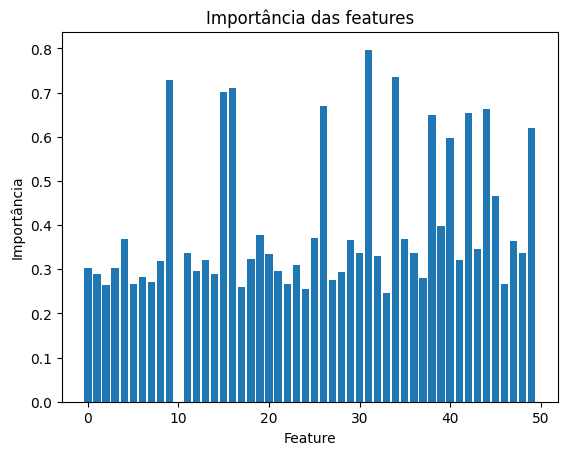

In [ ]:
import matplotlib.pyplot as plt

# Plot da importância das features para o nó especificado por node_idx. 
# A variável feat_mask contém os valores de importância das features, que são extraídos da 
# explicação gerada pelo explainer. O gráfico de barras mostra a importância de cada feature, 
# permitindo visualizar quais características tiveram maior impacto na previsão do modelo para aquele nó específico.
feat_mask = explanation.node_mask[node_idx].cpu().detach().numpy()

plt.figure()
plt.bar(range(len(feat_mask)), feat_mask)
plt.title("Importância das features")
plt.xlabel("Feature")
plt.ylabel("Importância")
plt.show()